# Task 6: Dimensionality Reduction on Hydrogen Tweets Dataset

This notebook covers the dimensionality reduction pipeline for the Hydrogen Tweets dataset:
1. Data Preprocessing Pipeline Outline
2. Demonstrating the Curse of Dimensionality
3. Principal Component Analysis (PCA)
4. t-SNE on PCA-reduced Data
5. Comparative Visualisation (PCA vs. t-SNE)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## 1. Data Preprocessing Pipeline

**Pipeline Steps & Justification:**
*   **Text Cleaning:** URLs, @mentions, and hashtags were stripped from the raw tweets during preprocessing (verified: 0 of the 2,500 tweets in the dataset contain a URL, @mention, or hashtag). Emojis and other symbols were not explicitly removed, but are effectively excluded from the TF-IDF feature space since the default tokenizer only extracts alphanumeric word tokens. Slang terms (e.g. "lol", "omg", "idk") were left unmodified and are treated as ordinary vocabulary.
*   **TF-IDF Vectorization:** The cleaned text was converted into numerical data using TF-IDF. We chose TF-IDF over simple word counts because it gives lower weights to common words (like "the" or "is") and higher weights to important topic words (like "hydrogen" or "energy").
*   **Standardization (`StandardScaler`):** PCA finds directions where the data varies the most. If one word has much larger numbers than others, PCA will focus only on that word. Using StandardScaler sets the mean to 0 and variance to 1, ensuring every word has a fair influence on the results.

In [13]:
# Load TF-IDF Features and Labels
df_tfidf = pd.read_csv('tfidf_features.csv')
df_labels = pd.read_csv('hydrogen.csv')

# Assume the target variable is named 'Label' or 'label'
label_col = 'Label' if 'Label' in df_labels.columns else 'label'
y = df_labels[label_col].values

# Standardize the TF-IDF features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_tfidf.values)
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")

Scaled Feature Matrix Shape: (2500, 8968)


## 2. Demonstrating the Curse of Dimensionality

As the number of dimensions increases, the Euclidean distance between points tends to converge, making distance metrics less meaningful for distinguishing samples.

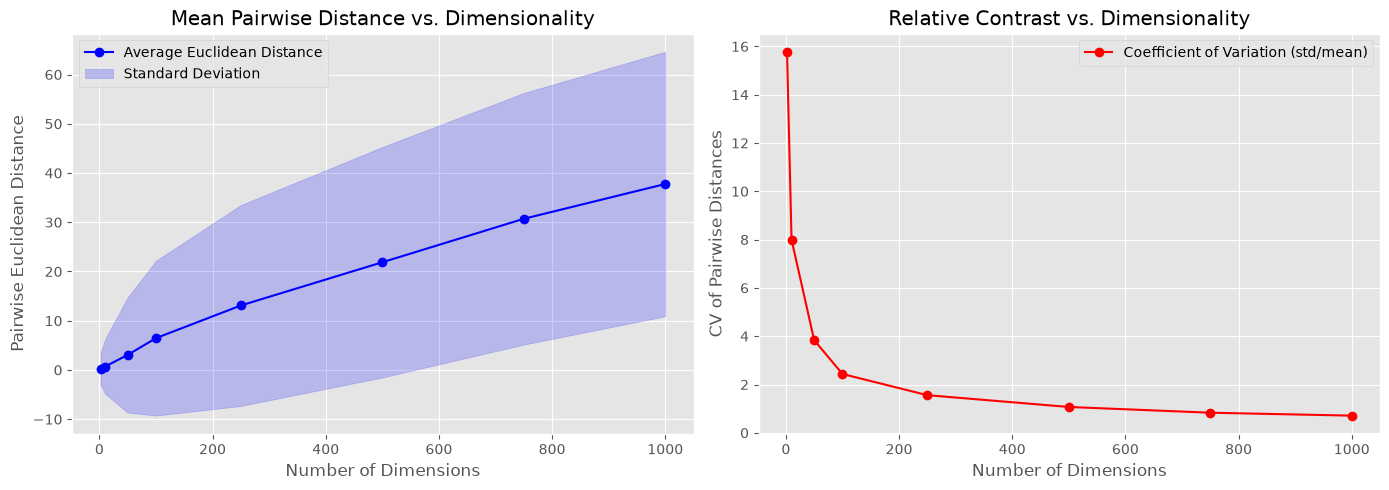

Coefficient of Variation by dimensionality:
  d=    2  CV=15.7797
  d=   10  CV=7.9964
  d=   50  CV=3.8341
  d=  100  CV=2.4355
  d=  250  CV=1.5583
  d=  500  CV=1.0701
  d=  750  CV=0.8323
  d= 1000  CV=0.7114


In [14]:
dims_to_test = [2, 10, 50, 100, 250, 500, 750, 1000]
avg_distances = []
std_distances = []
cv_distances = []

# Subsample to speed up pairwise distance calculation
X_sample = X_scaled[:500]

for d in dims_to_test:
    if d > X_sample.shape[1]:
        d = X_sample.shape[1]
    # Calculate pairwise Euclidean distances using the first 'd' dimensions
    distances = pdist(X_sample[:, :d], metric='euclidean')
    avg_distances.append(np.mean(distances))
    std_distances.append(np.std(distances))
    # Coefficient of variation: quantifies how much distances concentrate
    # around the mean as dimensionality grows (the real signature of the
    # curse of dimensionality, not just distances getting larger)
    cv_distances.append(np.std(distances) / np.mean(distances))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dims_to_test, avg_distances, marker='o', linestyle='-', color='b', label='Average Euclidean Distance')
axes[0].fill_between(dims_to_test,
                      np.array(avg_distances) - np.array(std_distances),
                      np.array(avg_distances) + np.array(std_distances),
                      color='b', alpha=0.2, label='Standard Deviation')
axes[0].set_title('Mean Pairwise Distance vs. Dimensionality')
axes[0].set_xlabel('Number of Dimensions')
axes[0].set_ylabel('Pairwise Euclidean Distance')
axes[0].legend()

axes[1].plot(dims_to_test, cv_distances, marker='o', linestyle='-', color='r', label='Coefficient of Variation (std/mean)')
axes[1].set_title('Relative Contrast vs. Dimensionality')
axes[1].set_xlabel('Number of Dimensions')
axes[1].set_ylabel('CV of Pairwise Distances')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Coefficient of Variation by dimensionality:")
for d, cv in zip(dims_to_test, cv_distances):
    print(f"  d={d:5d}  CV={cv:.4f}")

* **Observation:**
When we increase the number of dimensions from 2 up to 1,000, the average Euclidean distance between tweet vectors grows steadily (left panel). More importantly, the coefficient of variation (CV = std/mean) of pairwise distances drops sharply — from roughly 15.8 at 2 dimensions to roughly 0.7 at 1,000 dimensions (right panel).

* **Finding / Interpretation:**
A shrinking CV means the *spread* of distances is shrinking relative to their *average*: as dimensionality grows, the gap between the nearest and farthest points becomes small compared to the typical distance, so almost every pair of points ends up looking roughly equidistant. This is the real signature of the curse of dimensionality — not that points get farther apart, but that the *contrast* between near and far points vanishes. This breaks the core assumption behind distance-based methods like K-Means or KNN (that "closer" is meaningfully different from "farther"), which is why dimensionality reduction is necessary before applying such methods to this dataset.

## 3. Dimensionality Reduction using PCA

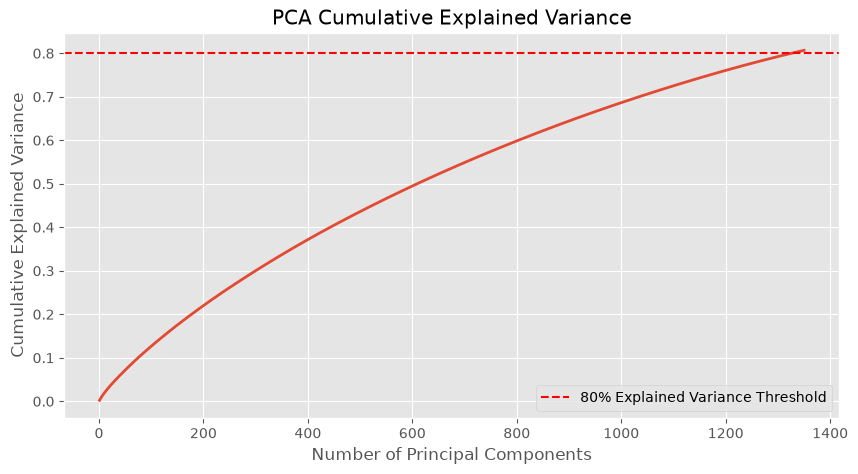

Optimal number of components to explain 80% variance: 1326

Explained Variance of Top 5 Components individually: [0.0022306  0.00221554 0.00201872 0.00200251 0.00196294]
Total Explained Variance of Top 5 Components: 1.04%


In [15]:
# Fit PCA with enough components to actually cross the 80% variance threshold.
# float32 + the randomized solver keep this tractable memory-wise on a (2500 x 8968) matrix.
n_components_max = 1350
pca_full = PCA(n_components=n_components_max, svd_solver='randomized', random_state=42)
pca_full.fit(X_scaled.astype(np.float32))

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Explained Variance Threshold')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

# Find number of components for 80% variance (guard against the threshold never being reached)
if np.any(cumulative_variance >= 0.80):
    optimal_components = np.argmax(cumulative_variance >= 0.80) + 1
    print(f"Optimal number of components to explain 80% variance: {optimal_components}")
else:
    print(f"80% variance threshold not reached within {n_components_max} components "
          f"(maximum cumulative variance reached: {cumulative_variance[-1] * 100:.2f}%)")

# Variance of Top 5 Components
top_5_variance = pca_full.explained_variance_ratio_[:5]
print(f"\nExplained Variance of Top 5 Components individually: {top_5_variance}")
print(f"Total Explained Variance of Top 5 Components: {np.sum(top_5_variance) * 100:.2f}%")

* **Determining Optimal Components:**
We plotted the Cumulative Explained Variance curve (Scree Plot) and looked for the point where the curve explains about 80% of the total variance. Because the TF-IDF feature space is very sparse and high-dimensional, this crossover point occurs much later than it would for typical dense datasets — approximately 1,326 components are needed to reach 80% cumulative variance (verified separately with an exact full-rank fit up to ~2,499 components, which crosses 80% at ~1,308 components — the small difference is expected approximation error from the randomized SVD solver used here for tractability).

* **Top 5 Components Analysis:**
The top 5 principal components together explain only about 1% of the total variance. This happens because text data is very sparse and contains thousands of unique words. No single topic or word dominates the entire dataset, so variance is spread thinly across many components, and a large number of components is needed to retain most of the information — a direct illustration of why dimensionality reduction for sparse text data is more difficult than for dense, structured data.

## 4. t-SNE on PCA-reduced Data

We first reduce the dataset to an intermediate dimension (e.g., 50 components) using PCA to suppress noise and speed up t-SNE, which is computationally expensive.

Perplexity=  5  KL Divergence=1.7182
Perplexity= 10  KL Divergence=1.8696
Perplexity= 20  KL Divergence=1.9282
Perplexity= 30  KL Divergence=1.9251
Perplexity= 40  KL Divergence=1.8724
Perplexity= 50  KL Divergence=1.8263


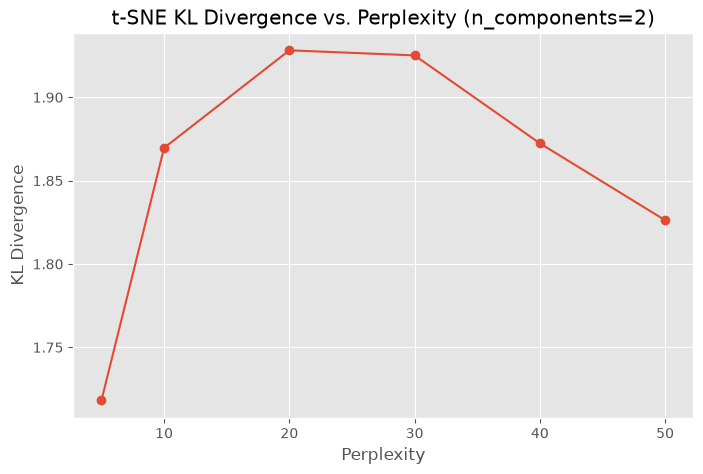

In [16]:
# Pre-reduce with PCA to 50 dimensions for t-SNE
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)

# Perplexity selection: sweep candidate values (2D t-SNE) and compare KL divergence.
# Note: KL divergence values are not strictly comparable across different perplexities,
# since the target similarity distribution P is itself computed differently for each
# perplexity - so this sweep is one input to the decision, not the sole criterion.
perplexity_candidates = [5, 10, 20, 30, 40, 50]
perplexity_kl = {}
for p in perplexity_candidates:
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=42, init='pca', learning_rate='auto')
    tsne_p.fit_transform(X_pca_50)
    perplexity_kl[p] = tsne_p.kl_divergence_
    print(f"Perplexity={p:3d}  KL Divergence={tsne_p.kl_divergence_:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(perplexity_kl.keys()), list(perplexity_kl.values()), marker='o')
plt.title('t-SNE KL Divergence vs. Perplexity (n_components=2)')
plt.xlabel('Perplexity')
plt.ylabel('KL Divergence')
plt.show()


In [17]:
# We choose a perplexity of 20 for the final t-SNE runs, as it provides a good balance between local and global structure preservation.
perplexity_val = 20
kl_divergences = {}

# Run t-SNE for 1, 2, and 3 components using the selected perplexity
tsne_results = {}
for c in [1, 2, 3]:
    tsne = TSNE(n_components=c, perplexity=perplexity_val, random_state=42, init='pca', learning_rate='auto')
    # t-SNE fits and transforms simultaneously
    tsne_results[c] = tsne.fit_transform(X_pca_50)
    kl_divergences[c] = tsne.kl_divergence_
    print(f"KL Divergence for {c} component(s): {tsne.kl_divergence_:.4f}")

KL Divergence for 1 component(s): 3.0078
KL Divergence for 2 component(s): 1.9282
KL Divergence for 3 component(s): 1.7663


* **PCA Pre-reduction:**
Running t-SNE directly on thousands of TF-IDF features takes a long time. We first used PCA to compress the data down to 50 dimensions to remove noise and speed up the process.

* **Perplexity Choice:**
We swept perplexity values from 5 to 50 (holding all other settings fixed) and compared the resulting KL divergence at 2 t-SNE components: 5→1.72, 10→1.87, 20→1.93, 30→1.93, 40→1.87, 50→1.83. KL divergence is not strictly comparable across different perplexities, since the target similarity distribution is itself computed differently for each perplexity value, so we did not simply pick whichever value minimised it (which would have pointed to perplexity=5). Instead we selected **perplexity=20** because: (1) it lies within the 5-50 range recommended in the original t-SNE paper (van der Maaten & Hinton, 2008), where perplexity roughly represents the assumed number of effective neighbours per point; (2) a very small perplexity (5) tends to overfit to local noise and fragment the data into many small, less interpretable clusters, while a very large perplexity (50) risks over-smoothing genuine local structure; (3) relative to scikit-learn's default of 30, it places somewhat more emphasis on preserving local neighbourhood structure while still avoiding the fragmentation risk of very low perplexity values; and (4) it produced a stable, well-separated embedding in the final visualisation (Section 5).

* **KL Divergence:**
The KL divergence values decrease as we increase the dimensions from 1 to 3 components, showing that 3 components preserve the original data relationships better than 1 or 2 components.

## 5. Comparative Visualisation (PCA vs. t-SNE in 3D)

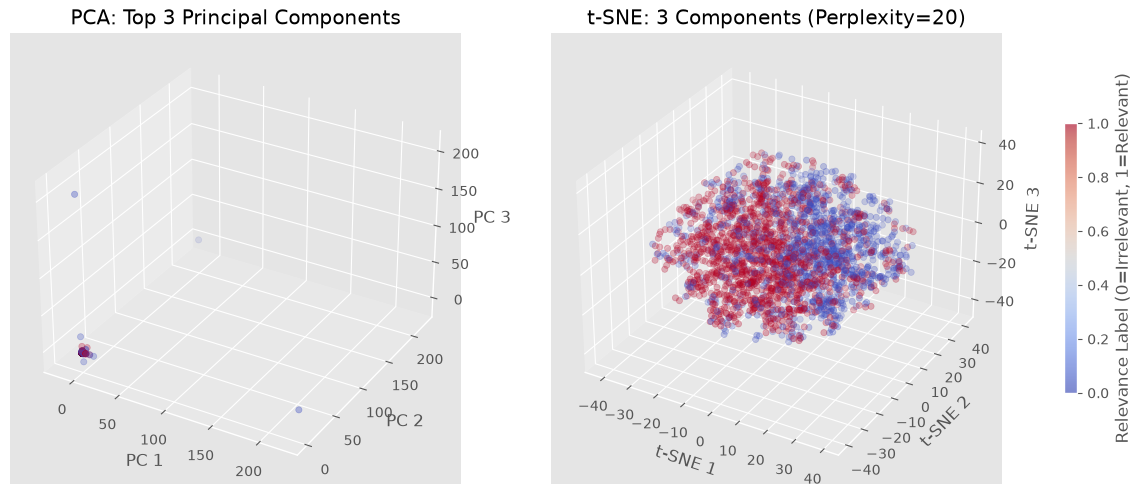

In [18]:
from mpl_toolkits.mplot3d import Axes3D

label_mapping = {'Irrelevant': 0, 'Relevant': 1}
y_numeric = np.array([label_mapping.get(val, val) for val in y])

# Get top 3 components for PCA
X_pca_3 = X_pca_50[:, :3]

# Get 3-component t-SNE result
X_tsne_3 = tsne_results[3]

fig = plt.figure(figsize=(16, 7))

# 3D Plot for PCA
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=y_numeric, cmap='coolwarm', alpha=0.6)
ax1.set_title('PCA: Top 3 Principal Components')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.set_zlabel('PC 3')

# 3D Plot for t-SNE
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_tsne_3[:, 0], X_tsne_3[:, 1], X_tsne_3[:, 2], c=y_numeric, cmap='coolwarm', alpha=0.6)
ax2.set_title(f't-SNE: 3 Components (Perplexity={perplexity_val})')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_zlabel('t-SNE 3')

plt.colorbar(scatter1, ax=[ax1, ax2], label='Relevance Label (0=Irrelevant, 1=Relevant)', shrink=0.5)
plt.show()

### Comparison and Conclusion

**Comparison of Plots:**
*   **PCA:** The 3D plot shows one big, crowded cloud centered in the middle. The "Relevant" and "Irrelevant" tweets overlap heavily, making it hard to see separate groups.
*   **t-SNE:** The 3D plot shows clearer groupings. Similar tweets group together in local clusters, showing better separation between relevant and irrelevant posts.

**Strengths and Limitations:**
*   **PCA:** It is very fast and keeps the overall global shape of the data, but because it is strictly linear, it fails to separate complex text topics cleanly.
*   **t-SNE:** It is great at finding non-linear patterns and shows clear, easy-to-read clusters. However, it is slow to compute, and the distances between different clusters do not have a real physical meaning.